In [5]:
# Cell 1 — imports & settings
import os, sys, copy, time
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, datasets, models

from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, f1_score,
    confusion_matrix, classification_report
)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Paths / hyperparams
DATASET_FOLDER = os.path.join("archive", "nih_imagefolder")  # Prepared NIH ImageFolder output
DATA_ROOT = os.environ.get("PNEUMONIA_DATA_ROOT", os.path.join(os.getcwd(), DATASET_FOLDER))

WORKING_DIR = "./updated1_output"                     # Folder to save models and plots
os.makedirs(WORKING_DIR, exist_ok=True)      # Create it if it doesn't exist

IMG_SIZE = 224
BATCH = 16
NUM_WORKERS = 2
SEED = 42

EPOCHS_STAGE1 = 6
EPOCHS_STAGE2 = 10
LR_STAGE1 = 1e-4
LR_STAGE2 = 1e-5

USE_MIXUP = True
MIXUP_ALPHA = 0.2
USE_SAMPLER = False   # set True to use WeightedRandomSampler
FINE_TUNE_FRAC = 0.8  # fraction of feature-groups to freeze (unfreeze last 1-FINE_TUNE_FRAC)

Device: cpu


In [6]:
# Cell 2 — sanity checks + seed
def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# check prepared NIH ImageFolder location
missing_splits = [split for split in ("train", "val", "test") if not os.path.isdir(os.path.join(DATA_ROOT, split))]
if missing_splits:
    raise FileNotFoundError(
        f"Prepared NIH dataset not found at {DATA_ROOT}. Run prepare_nih_xray14.py first. "
        f"Missing: {', '.join(missing_splits)}."
    )
print("Found dataset root:", DATA_ROOT)
print("Subfolders:", os.listdir(DATA_ROOT))

Found dataset root: d:\Pneumonia-Detection-from-CXR-Using-CNN-ViT-Ensemble-with-Post-hoc-Calibration-Technique-main\archive\nih_imagefolder
Subfolders: ['metadata_used.csv', 'test', 'train', 'val']


In [7]:
# Cell 3 — transforms and datasets
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

train_dir = os.path.join(DATA_ROOT, "train")
val_dir   = os.path.join(DATA_ROOT, "val")
test_dir  = os.path.join(DATA_ROOT, "test")

# Note: Will raise an error if folders don't exist yet
train_ds = datasets.ImageFolder(train_dir, transform=train_transform)
val_ds   = datasets.ImageFolder(val_dir, transform=val_transform)
test_ds  = datasets.ImageFolder(test_dir, transform=val_transform)

print("Classes:", train_ds.classes)
print("Sizes -> train:", len(train_ds), "val:", len(val_ds), "test:", len(test_ds))

Classes: ['NORMAL', 'PNEUMONIA']
Sizes -> train: 41054 val: 10322 test: 10416


In [8]:
import sys
print(sys.executable)

import tabulate
print(tabulate.__version__)

c:\Users\CSE\AppData\Local\Python\pythoncore-3.14-64\python.exe
0.10.0


In [9]:
# Cell 4 — 20% training subset, class counts, and dataloaders

TRAIN_FRACTION = 0.20

train_targets = np.asarray(train_ds.targets)
rng = np.random.default_rng(SEED)

subset_indices = []
for class_idx in range(len(train_ds.classes)):
    class_indices = np.flatnonzero(train_targets == class_idx)
    sample_size = max(1, int(len(class_indices) * TRAIN_FRACTION))
    subset_indices.extend(
        rng.choice(class_indices, size=sample_size, replace=False).tolist()
    )

train_subset = torch.utils.data.Subset(train_ds, subset_indices)

counts = Counter(int(train_targets[i]) for i in subset_indices)
print(f"Using {len(train_subset)} of {len(train_ds)} training images")
print("Train class counts:", counts)

neg = counts.get(0, 0)
pos = counts.get(1, 0)
pos_weight = torch.tensor(
    [neg / max(1, pos)],
    dtype=torch.float32,
    device=DEVICE
)

if USE_SAMPLER:
    class_sample_counts = [counts[i] for i in range(len(train_ds.classes))]
    weights = 1.0 / torch.tensor(class_sample_counts, dtype=torch.float)
    sample_weights = [
        weights[int(train_targets[i])] for i in subset_indices
    ]
    sampler = WeightedRandomSampler(
        sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
else:
    sampler = None

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH,
    sampler=sampler,
    shuffle=(sampler is None),
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

Using 8210 of 41054 training images
Train class counts: Counter({0: 8068, 1: 142})


In [10]:
# Cell 5 — MixUp helpers
def mixup_data(x, y, alpha=MIXUP_ALPHA):
    if alpha <= 0:
        return x, y, None
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [11]:
# Cell 6 — model setup (ResNet-50)
model = models.resnet50(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1)   # single logit for ResNet
model = model.to(DEVICE)

# loss with pos_weight to handle imbalance
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# freeze features for stage1 (all children except 'fc')
for name, child in model.named_children():
    if name != 'fc':
        for p in child.parameters():
            p.requires_grad = False

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_STAGE1, weight_decay=1e-4)

print("Model created. Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

C:\Users\CSE\AppData\Roaming\Python\Python314\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\CSE\AppData\Roaming\Python\Python314\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model created. Trainable params: 2049


In [12]:
# Cell 7 — Training, Evaluation, and EarlyStopping functions
class EarlyStopping:
    """Stops training if validation metric doesn't improve after a given patience."""
    def __init__(self, patience=5, delta=0.0, mode='max', path='checkpoint.pth'):
        self.patience = patience
        self.delta = delta
        self.mode = mode
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, current_metric, model):
        score = current_metric if self.mode == 'max' else -current_metric
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(current_metric, model)
        elif score <= self.best_score + self.delta:
            self.counter += 1
            print(f"  --> EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(current_metric, model)
            self.counter = 0

    def save_checkpoint(self, current_metric, model):
        print(f"  --> Validation metric improved to {current_metric:.4f}. Saving model...")
        torch.save(model.state_dict(), self.path)

def train_one_epoch(model, loader, optimizer, criterion, device, use_mixup=USE_MIXUP, mixup_alpha=MIXUP_ALPHA):
    model.train()
    running_loss = 0.0
    all_logits, all_labels = [], []
    pbar = tqdm(loader, desc="Train", leave=False)
    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        if use_mixup:
            mixed_x, y_a, y_b, lam = mixup_data(imgs, labels, alpha=mixup_alpha)
            outputs = model(mixed_x)
            loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
            probs = torch.sigmoid(outputs).detach().cpu().numpy().flatten()
            soft_labels = (lam * y_a + (1 - lam) * y_b).detach().cpu().numpy().flatten()
            all_logits.extend(probs.tolist())
            all_labels.extend(soft_labels.tolist())
        else:
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            probs = torch.sigmoid(outputs).detach().cpu().numpy().flatten()
            all_logits.extend(probs.tolist())
            all_labels.extend(labels.detach().cpu().numpy().flatten().tolist())

        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        pbar.set_postfix(loss=running_loss / (len(all_labels) + 1e-9))

    epoch_loss = running_loss / len(loader.dataset)
    preds = (np.array(all_logits) >= 0.5).astype(int)
    true = np.array(all_labels).astype(int)
    acc = accuracy_score(true, preds) if len(true)>0 else float("nan")
    try:
        auc = roc_auc_score(true, np.array(all_logits))
    except Exception:
        auc = float("nan")
    return epoch_loss, acc, auc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_logits, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Eval", leave=False):
            imgs = imgs.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            all_logits.extend(probs.tolist())
            all_labels.extend(labels.cpu().numpy().flatten().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    preds = (np.array(all_logits) >= 0.5).astype(int)
    true = np.array(all_labels).astype(int)
    acc = accuracy_score(true, preds) if len(true)>0 else float("nan")
    try:
        auc = roc_auc_score(true, np.array(all_logits))
    except Exception:
        auc = float("nan")
    return epoch_loss, acc, auc, np.array(all_labels), np.array(all_logits)


STARTING RESNET50 TRAINING | NO MIXUP



--- Training one epoch ---


Train:   0%|          | 0/514 [00:00<?, ?it/s]C:\Users\CSE\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Eval:   0%|          | 0/646 [00:00<?, ?it/s]                      C:\Users\CSE\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/1 | Loss: 1.3619/1.3002 | Acc: 0.7001/0.5987 | AUC: 0.5279/0.6036
  --> Validation metric improved to 0.6036. Saving model...


Eval:   0%|          | 0/651 [00:00<?, ?it/s]C:\Users\CSE\AppData\Roaming\Python\Python314\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



FINAL RESULTS
Test loss:      2.6888
Test accuracy:  0.4278
Test AUC:       0.5827
Best F1:        0.1265
Best threshold: 0.520

| Metric         | ResNet50 - No MixUp   |
|:---------------|:----------------------|
| Test Accuracy  | 42.78%                |
| Test AUC       | 0.5827                |
| Best F1        | 0.1265                |
| Best Threshold | 0.520                 |


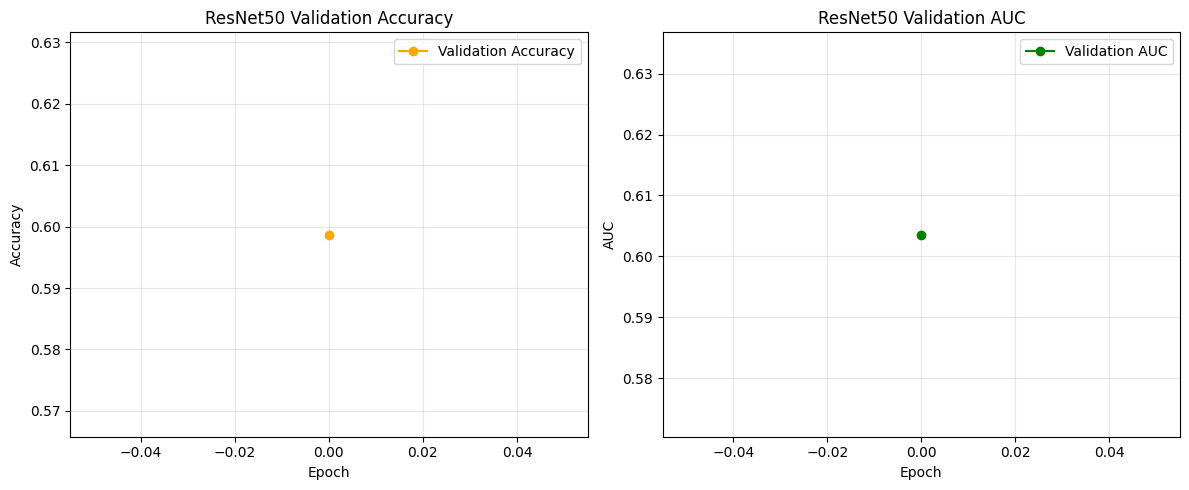

In [13]:
# Cell 8 — One-epoch, no-MixUp ResNet50 training

def run_training():
    print("\n" + "=" * 50)
    print("STARTING RESNET50 TRAINING | NO MIXUP")
    print("=" * 50 + "\n")

    model = models.resnet50(weights="DEFAULT")
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 1)
    model = model.to(DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # Freeze backbone and train only the classification layer
    for name, child in model.named_children():
        if name != "fc":
            for parameter in child.parameters():
                parameter.requires_grad = False

    optimizer = optim.Adam(
        filter(lambda parameter: parameter.requires_grad, model.parameters()),
        lr=LR_STAGE1
    )

    history = {
        "train_acc": [],
        "val_acc": [],
        "train_auc": [],
        "val_auc": [],
        "train_loss": [],
        "val_loss": []
    }

    checkpoint_path = os.path.join(
        WORKING_DIR,
        "best_s1_resnet50_nomixup.pth"
    )

    early_stopping = EarlyStopping(
        patience=3,
        mode="max",
        path=checkpoint_path
    )

    print("--- Training one epoch ---")

    for epoch in range(1):
        train_loss, train_acc, train_auc = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=DEVICE,
            use_mixup=False
        )

        val_loss, val_acc, val_auc, _, _ = evaluate(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=DEVICE
        )

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_auc"].append(train_auc)
        history["val_auc"].append(val_auc)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(
            f"Epoch {epoch + 1}/1 | "
            f"Loss: {train_loss:.4f}/{val_loss:.4f} | "
            f"Acc: {train_acc:.4f}/{val_acc:.4f} | "
            f"AUC: {train_auc:.4f}/{val_auc:.4f}"
        )

        # Use validation AUC for checkpoint selection
        early_stopping(val_auc, model)

    model.load_state_dict(
        torch.load(checkpoint_path, map_location=DEVICE)
    )

    test_loss, test_acc, test_auc, y_true, y_probs = evaluate(
        model=model,
        loader=test_loader,
        criterion=criterion,
        device=DEVICE
    )

    best_threshold = 0.5
    best_f1 = 0.0

    for threshold in np.linspace(0.1, 0.9, 81):
        predictions = (y_probs >= threshold).astype(int)
        current_f1 = f1_score(
            y_true,
            predictions,
            zero_division=0
        )

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = threshold

    print("\n" + "=" * 50)
    print("FINAL RESULTS")
    print("=" * 50)
    print(f"Test loss:      {test_loss:.4f}")
    print(f"Test accuracy:  {test_acc:.4f}")
    print(f"Test AUC:       {test_auc:.4f}")
    print(f"Best F1:        {best_f1:.4f}")
    print(f"Best threshold: {best_threshold:.3f}")

    return {
        "history": history,
        "test_acc": test_acc,
        "test_auc": test_auc,
        "test_loss": test_loss,
        "best_f1": best_f1,
        "best_thr": best_threshold
    }


# Run only one configuration: no MixUp
results_nomix = run_training()


# Display results
results_table = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Test AUC",
        "Best F1",
        "Best Threshold"
    ],
    "ResNet50 - No MixUp": [
        f"{results_nomix['test_acc'] * 100:.2f}%",
        f"{results_nomix['test_auc']:.4f}",
        f"{results_nomix['best_f1']:.4f}",
        f"{results_nomix['best_thr']:.3f}"
    ]
})

print("\n" + results_table.to_markdown(index=False))


# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(
    results_nomix["history"]["val_acc"],
    label="Validation Accuracy",
    color="orange",
    marker="o"
)
plt.title("ResNet50 Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(
    results_nomix["history"]["val_auc"],
    label="Validation AUC",
    color="green",
    marker="o"
)
plt.title("ResNet50 Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()